# Detecção de buracos em pavimento — CNN baseline e transfer learning

## Problema de negócio e impacto

Inspeção visual de pistas para identificar **áreas com buracos** é trabalhosa e subjetiva. Um modelo de visão computacional pode **priorizar trechos para manutenção**, reduzir custo de inspeção e padronizar critérios.

## Objetivo técnico (resumo)

- **Treinar** um classificador binário (pista normal vs. com buracos) com **CNN baseline** e com **transfer learning** (backbone ImageNet).
- **Garantir reprodutibilidade** (seeds, configuração centralizada, registro de ambiente).
- **Entregar artefatos** para campo: modelo salvo, métricas em CSV e célula de inferência em imagem nova.

## Abordagem

- Baseline: CNN leve treinada do zero sobre imagens redimensionadas.
- Transfer: **MobileNetV2** (rápido e leve para uso em campo); *EfficientNetB0* como alternativa no `CONFIG`.
- Treino em **duas fases**: cabeça com backbone congelado; depois *fine-tuning* das últimas camadas com taxa menor.


## Diagnóstico do estado anterior (baseline original)

Antes da evolução deste notebook, o pipeline era:

| Aspecto | Situação |
|--------|----------|
| **Arquitetura** | `Conv2D(32)→Pool→Conv2D(64)→Pool→Conv2D(128)→Pool→Flatten→Dense(128)→Dense(1, sigmoid)` em `src/deteccao_buracos.py` |
| **Loss / otimizador** | `binary_crossentropy`, `Adam` (defaults), métrica `accuracy` |
| **Pré-processamento** | Resize 128×128, RGB, normalização **[0, 1]** (não ImageNet) |
| **Augmentation** | Nenhuma |
| **Split** | 80/20 estratificado (`stratify=y`), mesma semente — **mantido abaixo** |
| **Métricas** | Acurácia, matriz de confusão, precision/recall/F1 por classe; **sem AUC** no treino |
| **Riscos** | Possível overfitting sem early stopping; desbalanceamento **sem** `class_weight`; seeds **parciais** (sem `random`/`PYTHONHASHSEED`) |

**Split de dados:** a lógica **não foi alterada** — continuamos usando `separar_treino_validacao` com `PROPORCAO_VALIDACAO_PADRAO` e `SEMENTE_PADRAO`.


## Configuração

Sementes globais, dicionário `CONFIG`, criação de pastas (`data/`, `models/`, `logs/`, `outputs/`) e registro de versões de bibliotecas.

**Dependências:** o carregamento de imagens e a inferência usam OpenCV (`cv2`). Há uma **célula de código** logo após o `pip freeze` que instala `opencv-python` neste kernel se faltar. Alternativa manual: `pip install opencv-python` (ou `%pip install opencv-python` no notebook) no **mesmo** ambiente do kernel.


In [19]:
# Reprodutibilidade: seeds e determinismo (GPU pode manter pequena variância).
import os
import random

import numpy as np
import tensorflow as tf

# CONFIG é definido na próxima célula; aqui usamos apenas SEED.
def configurar_sementes_globais(seed: int) -> None:
    # Fixa seeds para random, NumPy, TensorFlow e hash de Python.
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # Opcional: operações determinísticas (pode reduzir desempenho em GPU).
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

# Será chamado após CONFIG


In [20]:
from pathlib import Path
from types import SimpleNamespace

# Raiz do repositório (Colab: ajuste ou monte Drive e defina DATA_ROOT).
_raiz_atual = Path.cwd().resolve()
PROJETO_RAIZ = next((p for p in [_raiz_atual, *_raiz_atual.parents] if (p / "src").exists()), _raiz_atual)

# --- CONFIG centralizado (sem magic numbers espalhados) ---
CONFIG = {
    "SEED": 42,
    "DATA_ROOT": PROJETO_RAIZ / "datasets",  # Colab: Path("/content/drive/MyDrive/.../datasets")
    "IMG_SIZE": (128, 128),
    "BATCH_SIZE": 32,
    "EPOCHS_BASELINE": 10,
    "EPOCHS_HEAD": 30,
    "EPOCHS_FINETUNE": 30,
    "LR_HEAD": 1e-3,
    "LR_FINETUNE": 1e-5,
    "BACKBONE": "MobileNetV2",  # ou "EfficientNetB0"
    "UNFREEZE_LAYERS": 40,
    "EARLY_STOPPING_PATIENCE": 10,
    "DEMO_IMAGE": None,  # ex.: PROJETO_RAIZ / "datasets" / "whole-detection" / "archive" / "normal" / "foo.jpg"
    "USE_GRADCAM": True,
    "DIR_DATA": PROJETO_RAIZ / "data",
    "DIR_MODELS": PROJETO_RAIZ / "models",
    "DIR_LOGS": PROJETO_RAIZ / "logs",
    "DIR_OUTPUTS": PROJETO_RAIZ / "outputs",
    "RESULTS_CSV": PROJETO_RAIZ / "outputs" / "results.csv",
    "CHECKPOINT_HEAD": PROJETO_RAIZ / "models" / "transfer_phase1_best.keras",
    "CHECKPOINT_FINETUNE": PROJETO_RAIZ / "models" / "transfer_phase2_best.keras",
}

for _d in (CONFIG["DIR_DATA"], CONFIG["DIR_MODELS"], CONFIG["DIR_LOGS"], CONFIG["DIR_OUTPUTS"]):
    _d.mkdir(parents=True, exist_ok=True)

CFG = SimpleNamespace(**CONFIG)
configurar_sementes_globais(CONFIG["SEED"])
print("PROJETO_RAIZ:", PROJETO_RAIZ)


PROJETO_RAIZ: C:\Users\luccasoares\Desktop\Civil-Engineering


In [21]:
# Versões de ambiente (pip freeze filtrado — compatível com Colab).
import subprocess
import sys

_pkgs = (
    "tensorflow",
    "keras",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "opencv-python",
    "pillow",
    "jupyter",
)
try:
    out = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True, stderr=subprocess.STDOUT)
    for linha in out.splitlines():
        if any(linha.lower().startswith(p) for p in _pkgs):
            print(linha)
except Exception as e:
    print("pip freeze:", e)
print("Python:", sys.version)


jupyter @ file:///C:/b/abs_03nm7xrhxz/croot/jupyter_1709837239940/work
jupyter-console @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/jupyter_console_1707430148515/work
jupyter-events @ file:///C:/b/abs_c2m9s5b5m5/croot/jupyter_events_1718738115254/work
jupyter-lsp @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/jupyter-lsp-meta_1701806528286/work
jupyter_client @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/jupyter_client_1701796382758/work
jupyter_core @ file:///C:/b/abs_beftpbuevw/croot/jupyter_core_1718818307097/work
jupyter_server @ file:///C:/b/abs_9a333nh6yu/croot/jupyter_server_1718827092223/work
jupyter_server_terminals @ file:///C:/Users/dev-admin/perseverance-python-buildout/croot/jupyter_server_terminals_1701798041635/work
jupyterlab @ file:///C:/b/abs_88qjk9lo2r/croot/jupyterlab_1725895228333/work
jupyterlab-pygments @ file:///tmp/build/80754af9/jupyterlab_pygments_1601490720602/work
jupyterlab-widgets @ file:///tmp/build/8

In [22]:
# Instala opencv-python no interpretador DESTE kernel (mesmo que sys.executable).
# Rode esta célula uma vez se aparecer erro "No module named 'cv2'" ao carregar imagens.
import subprocess
import sys

try:
    import cv2  # noqa: F401
    print("opencv-python já disponível (cv2 importou com sucesso).")
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "opencv-python"],
    )
    import cv2  # noqa: F401
    print("opencv-python instalado. Pode seguir para a célula de imports.")


opencv-python instalado. Pode seguir para a célula de imports.


In [23]:
import sys
from pathlib import Path

# OpenCV: rode a célula anterior se ainda não tiver cv2; src.deteccao_buracos carrega cv2 sob demanda.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

if str(PROJETO_RAIZ) not in sys.path:
    sys.path.insert(0, str(PROJETO_RAIZ))

from src.deteccao_buracos import (
    MAPA_CLASSES,
    PROPORCAO_VALIDACAO_PADRAO,
    SEMENTE_PADRAO,
    avaliar_modelo,
    carregar_imagens_rotuladas,
    construir_cnn_baseline,
    obter_caminhos_dataset,
    obter_cv2,
    separar_treino_validacao,
    treinar_modelo,
)
from src.deteccao_buracos_transfer import (
    MetricasValidacaoCallback,
    anexar_historico_csv,
    avaliar_modelo_softmax,
    calcular_class_weight_dict,
    congelar_backbone,
    construir_modelo_transfer_completo,
    descongelar_ultimas_camadas_backbone,
    grad_cam_mobilenet,
    montar_tf_dataset_treino,
    montar_tf_dataset_validacao,
    obter_preprocess_input,
    preprocess_numpy_rgb_01,
)

sns.set_theme(style="whitegrid")


## Dados

Carregamento a partir de `DATA_ROOT` (subpastas `whole-detection/archive/normal` e `buracos` ou `potholes`). Imagens em **[0, 1]** no baseline; o modelo de transfer aplica **augmentation** + **pré-processamento ImageNet** no `tf.data`.


In [24]:
# Caminhos do dataset (DATA_ROOT abstrai local vs Colab).
caminhos = obter_caminhos_dataset(raiz_datasets=CONFIG["DATA_ROOT"])
print("Caminhos:", caminhos)

IMG_H, IMG_W = CONFIG["IMG_SIZE"]
TAMANHO = (IMG_H, IMG_W)

X, y = carregar_imagens_rotuladas(caminhos["base"], TAMANHO)
print("X:", X.shape, "y:", y.shape, "min/max:", X.min(), X.max())
classes_unicas, contagens = np.unique(y, return_counts=True)
print("Distribuição:", dict(zip(classes_unicas.tolist(), contagens.tolist())))


Caminhos: {'base': 'C:\\Users\\luccasoares\\Desktop\\Civil-Engineering\\datasets\\whole-detection\\archive', 'normal': 'C:\\Users\\luccasoares\\Desktop\\Civil-Engineering\\datasets\\whole-detection\\archive\\normal', 'buracos': 'C:\\Users\\luccasoares\\Desktop\\Civil-Engineering\\datasets\\whole-detection\\archive\\potholes'}
X: (681, 128, 128, 3) y: (681,) min/max: 0.0 1.0
Distribuição: {0: 352, 1: 329}


C:\Users\luccasoares\AppData\Local\Temp\ipykernel_18784\3065993729.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_eda, y=valores, ax=axes[1], palette=["#2e8b57", "#cc3333"])


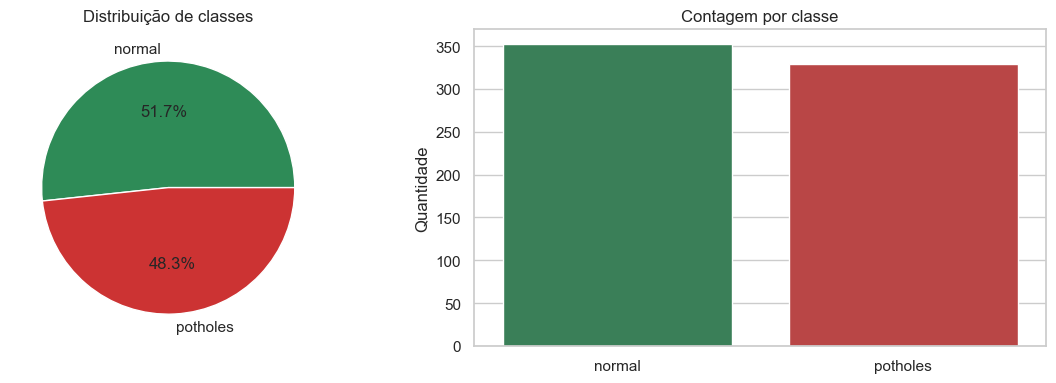

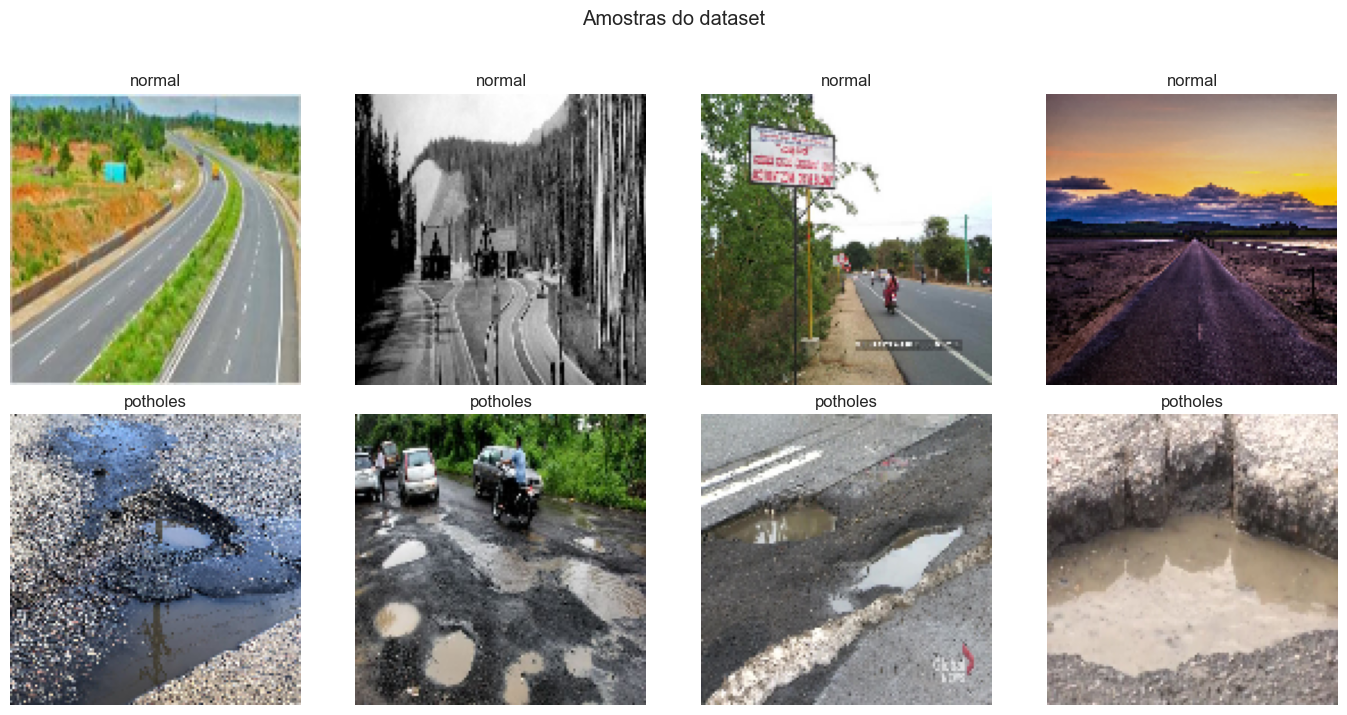

In [25]:
# EDA executiva: distribuição e grid com rótulos legíveis.
labels_eda = ["normal", "potholes"]
valores = [int(np.sum(y == 0)), int(np.sum(y == 1))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(valores, labels=labels_eda, autopct="%1.1f%%", colors=["#2e8b57", "#cc3333"])
axes[0].set_title("Distribuição de classes")
sns.barplot(x=labels_eda, y=valores, ax=axes[1], palette=["#2e8b57", "#cc3333"])
axes[1].set_title("Contagem por classe")
axes[1].set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
idx_n = np.where(y == MAPA_CLASSES["normal"])[0][:4]
idx_b = np.where(y == MAPA_CLASSES["buracos"])[0][:4]
for i, idx in enumerate(idx_n):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title("normal")
    axes[0, i].axis("off")
for i, idx in enumerate(idx_b):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title("potholes")
    axes[1, i].axis("off")
plt.suptitle("Amostras do dataset", y=1.02)
plt.tight_layout()
plt.show()


In [26]:
# Separação treino/validação — mesma lógica do projeto (estratificada).
X_treino, X_valid, y_treino, y_valid = separar_treino_validacao(
    X, y, PROPORCAO_VALIDACAO_PADRAO, SEMENTE_PADRAO
)
print(X_treino.shape, X_valid.shape)

forma_entrada = (IMG_H, IMG_W, 3)
class_weights = calcular_class_weight_dict(y_treino)
print("class_weight:", class_weights)


(544, 128, 128, 3) (137, 128, 128, 3)
class_weight: {0: 0.9679715302491103, 1: 1.0342205323193916}


## Modelo — baseline (CNN do zero)

Referência para comparação com transfer learning. Mesma divisão treino/validação.


In [27]:
# Baseline: CNN scratch + treino com arrays NumPy (como no projeto original).
modelo_baseline = construir_cnn_baseline(forma_entrada)
historico_baseline = treinar_modelo(
    modelo_baseline,
    X_treino,
    y_treino,
    X_valid,
    y_valid,
    epocas=CONFIG["EPOCHS_BASELINE"],
    batch_size=CONFIG["BATCH_SIZE"],
)
resultados_baseline = avaliar_modelo(modelo_baseline, X_valid, y_valid)

f1_b = float(resultados_baseline["relatorio_classificacao"]["macro avg"]["f1-score"])
acc_b = float(resultados_baseline["acuracia"])
# AUC para baseline (probabilidade classe positiva)
proba_b = np.asarray(resultados_baseline["probabilidades"], dtype=np.float64)
try:
    auc_b = float(roc_auc_score(y_valid, proba_b))
except ValueError:
    auc_b = float("nan")

metricas_baseline = {"accuracy": acc_b, "f1_macro": f1_b, "auc": auc_b}
print("Baseline:", metricas_baseline)


Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6022 - loss: 0.6784 - val_accuracy: 0.6934 - val_loss: 0.5328
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7549 - loss: 0.4613 - val_accuracy: 0.8029 - val_loss: 0.3943
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8984 - loss: 0.2442 - val_accuracy: 0.9051 - val_loss: 0.2396
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8868 - loss: 0.2893 - val_accuracy: 0.8686 - val_loss: 0.3088
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9209 - loss: 0.2125 - val_accuracy: 0.9124 - val_loss: 0.2104
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9283 - loss: 0.1854 - val_accuracy: 0.8759 - val_loss: 0.2584
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9452 - loss: 0.1509 - val_accuracy: 0.9489 - val_loss: 0.1724
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9633 - loss: 0.1059 - val_accuracy: 0.8978 - v

## Modelo — transfer learning (duas fases)

1. **Fase A:** backbone ImageNet **congelado**, treino do *head* (GAP → Dropout → Dense → softmax).
2. **Fase B:** **descongelar** as últimas `UNFREEZE_LAYERS` camadas, `LR_FINETUNE` menor.

Pipeline: `tf.data` com augmentation apenas no treino; validação só com pré-processamento ImageNet.


## Treinamento

Execução em duas fases com callbacks (`EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint`) e registro de métricas em `outputs/results.csv`.


In [28]:
# Fase A (cabeça): MobileNetV2/EfficientNet congelado + head softmax.
# tf.data aplica augmentation só no treino; validação só com preprocess ImageNet.
# class_weight corrige desbalanceamento; callbacks salvam melhor modelo e métricas.
preprocess_tf = obter_preprocess_input(CONFIG["BACKBONE"])

ds_treino = montar_tf_dataset_treino(
    X_treino,
    y_treino,
    CONFIG["BATCH_SIZE"],
    preprocess_tf,
    CONFIG["SEED"],
)
ds_valid = montar_tf_dataset_validacao(
    X_valid,
    y_valid,
    CONFIG["BATCH_SIZE"],
    preprocess_tf,
)

modelo_tl, backbone = construir_modelo_transfer_completo(
    CONFIG["BACKBONE"],
    forma_entrada,
    n_classes=2,
    dropout=0.3,
    pesos="imagenet",
)
congelar_backbone(backbone)

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["LR_HEAD"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_metrics_1 = MetricasValidacaoCallback(
    X_valid, y_valid, "head", CONFIG["BACKBONE"], CONFIG["BATCH_SIZE"]
)
early = EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    restore_best_weights=True,
)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)
ckpt1 = ModelCheckpoint(
    filepath=str(CONFIG["CHECKPOINT_HEAD"]),
    monitor="val_loss",
    save_best_only=True,
)

hist1 = modelo_tl.fit(
    ds_treino,
    epochs=CONFIG["EPOCHS_HEAD"],
    validation_data=ds_valid,
    class_weight=class_weights,
    callbacks=[early, reduce_lr, ckpt1, cb_metrics_1],
    verbose=1,
)
anexar_historico_csv(CONFIG["RESULTS_CSV"], cb_metrics_1.linhas, modo="w")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step - accuracy: 0.6173 - loss: 1.1521 - val_accuracy: 0.9781 - val_loss: 0.0827 - learning_rate: 0.0010 - val_f1: 0.9781 - val_auc: 0.9966
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.9655 - loss: 0.0937 - val_accuracy: 0.9562 - val_loss: 0.0823 - learning_rate: 0.0010 - val_f1: 0.9560 - val_auc: 0.9981
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.9918 - loss: 0.0445 - val_accuracy: 0.9708 - val_loss: 0.0729 - learning_rate: 0.0010 - val_f1: 0.9707 - val_auc: 0.9987
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.9843 - loss: 0.0539 - val_accuracy: 0.9781 - val_loss: 0.0745 - learning_rate: 0.0010 - val_f1: 0.9780 - val_auc: 0.9987
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.9816 - loss: 0.0390 - val_accuracy: 0.9562 - val_loss: 0.1212 - learning_rate: 0.0010 - val_f1: 0.9559 - val_auc: 0.9981
Epoch 6/30
17/17

In [29]:
# Fase B (fine-tuning): recarrega melhor peso da fase A, descongela UNFREEZE_LAYERS do backbone.

# LR menor (LR_FINETUNE) para não destruir pesos ImageNet; novo checkpoint na fase 2.

modelo_tl.load_weights(str(CONFIG["CHECKPOINT_HEAD"]))
descongelar_ultimas_camadas_backbone(backbone, CONFIG["UNFREEZE_LAYERS"])

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["LR_FINETUNE"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_metrics_2 = MetricasValidacaoCallback(
    X_valid, y_valid, "finetune", CONFIG["BACKBONE"], CONFIG["BATCH_SIZE"]
)
early2 = EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    restore_best_weights=True,
)
reduce_lr2 = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-8)
ckpt2 = ModelCheckpoint(
    filepath=str(CONFIG["CHECKPOINT_FINETUNE"]),
    monitor="val_loss",
    save_best_only=True,
)

hist2 = modelo_tl.fit(
    ds_treino,
    epochs=CONFIG["EPOCHS_FINETUNE"],
    validation_data=ds_valid,
    class_weight=class_weights,
    callbacks=[early2, reduce_lr2, ckpt2, cb_metrics_2],
    verbose=1,
)
anexar_historico_csv(CONFIG["RESULTS_CSV"], cb_metrics_2.linhas, modo="a")

# Melhor modelo final para avaliação
modelo_tl.load_weights(str(CONFIG["CHECKPOINT_FINETUNE"]))


Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step - accuracy: 0.9476 - loss: 0.1501 - val_accuracy: 0.9781 - val_loss: 0.0610 - learning_rate: 1.0000e-05 - val_f1: 0.9781 - val_auc: 0.9983
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.9585 - loss: 0.1061 - val_accuracy: 0.9781 - val_loss: 0.0637 - learning_rate: 1.0000e-05 - val_f1: 0.9781 - val_auc: 0.9985
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.9584 - loss: 0.1056 - val_accuracy: 0.9781 - val_loss: 0.0633 - learning_rate: 1.0000e-05 - val_f1: 0.9781 - val_auc: 0.9985
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - accuracy: 0.9647 - loss: 0.0945 - val_accuracy: 0.9781 - val_loss: 0.0617 - learning_rate: 1.0000e-05 - val_f1: 0.9781 - val_auc: 0.9985
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.9593 - loss: 0.0974 - val_accuracy: 0.9781 - val_loss: 0.0637 - learning_rate: 5.0000e-06 - val_f1: 0.9781 - val_auc: 0.9985
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176

## Avaliação e visualizações

Curvas de treino, matriz de confusão, acertos/erros e comparação baseline vs transfer.


Transfer learning: {'accuracy': 0.9781021897810219, 'f1_macro': 0.9780601078311002, 'auc': 0.9989329918907385}


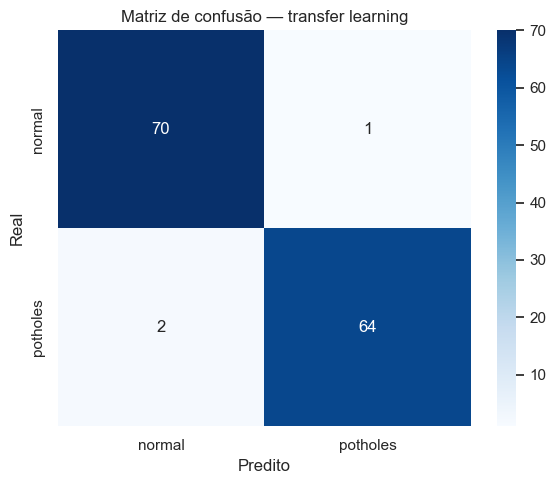

In [30]:
# Métricas finais no conjunto de validação (softmax + pré-processamento ImageNet).
resultados_tl = avaliar_modelo_softmax(
    modelo_tl, X_valid, y_valid, nome_backbone=CONFIG["BACKBONE"], batch_size=CONFIG["BATCH_SIZE"]
)
metricas_transfer = {
    "accuracy": resultados_tl["acuracia"],
    "f1_macro": resultados_tl["f1_macro"],
    "auc": resultados_tl["auc"],
}
print("Transfer learning:", metricas_transfer)

# Matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(
    resultados_tl["matriz_confusao"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "potholes"],
    yticklabels=["normal", "potholes"],
)
plt.title("Matriz de confusão — transfer learning")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


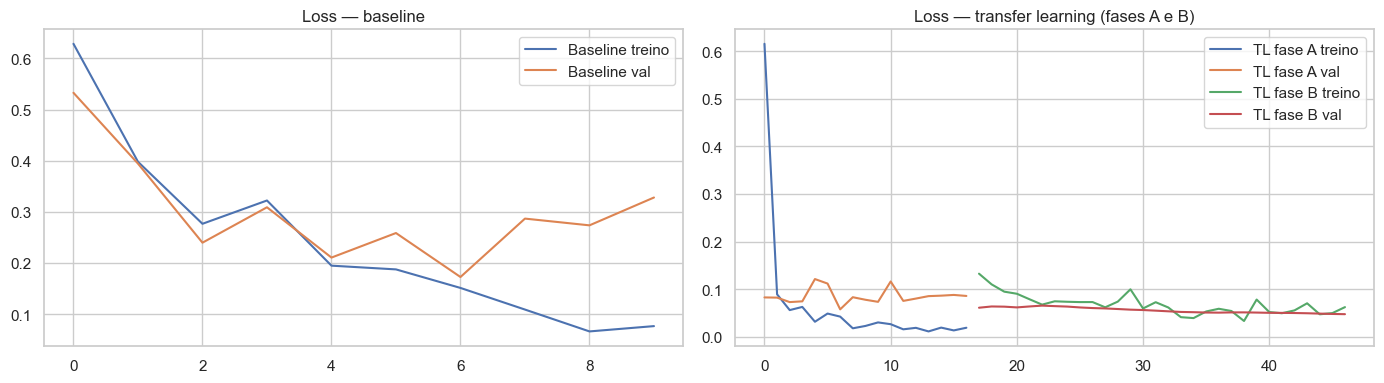

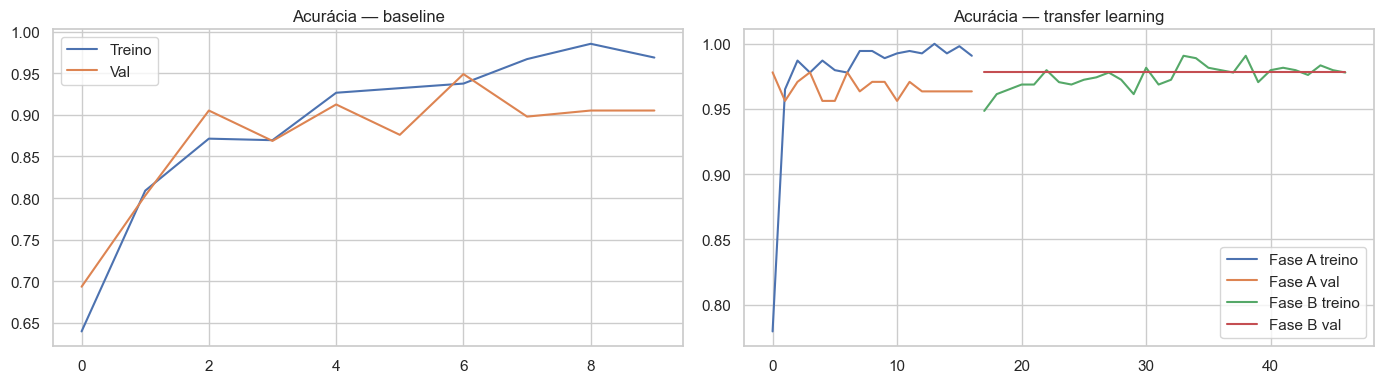

In [31]:
# Curvas loss e acurácia (baseline + transfer — duas fases concatenadas).
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(historico_baseline.history["loss"], label="Baseline treino")
axes[0].plot(historico_baseline.history["val_loss"], label="Baseline val")
axes[0].set_title("Loss — baseline")
axes[0].legend()

ep1 = len(hist1.history["loss"])
axes[1].plot(range(ep1), hist1.history["loss"], label="TL fase A treino")
axes[1].plot(range(ep1), hist1.history["val_loss"], label="TL fase A val")
off = ep1
axes[1].plot(range(off, off + len(hist2.history["loss"])), hist2.history["loss"], label="TL fase B treino")
axes[1].plot(range(off, off + len(hist2.history["val_loss"])), hist2.history["val_loss"], label="TL fase B val")
axes[1].set_title("Loss — transfer learning (fases A e B)")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(historico_baseline.history["accuracy"], label="Treino")
axes[0].plot(historico_baseline.history["val_accuracy"], label="Val")
axes[0].set_title("Acurácia — baseline")
axes[0].legend()

axes[1].plot(range(ep1), hist1.history["accuracy"], label="Fase A treino")
axes[1].plot(range(ep1), hist1.history["val_accuracy"], label="Fase A val")
axes[1].plot(range(off, off + len(hist2.history["loss"])), hist2.history["accuracy"], label="Fase B treino")
axes[1].plot(range(off, off + len(hist2.history["val_accuracy"])), hist2.history["val_accuracy"], label="Fase B val")
axes[1].set_title("Acurácia — transfer learning")
axes[1].legend()
plt.tight_layout()
plt.show()


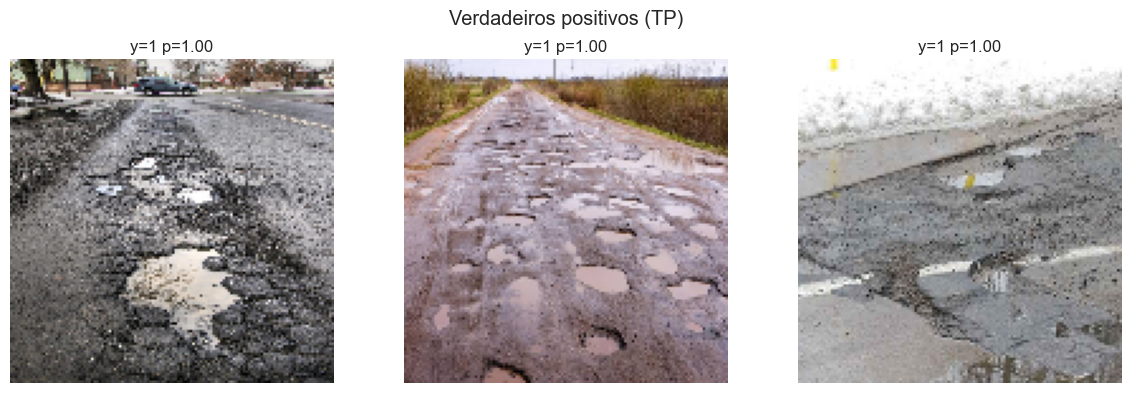

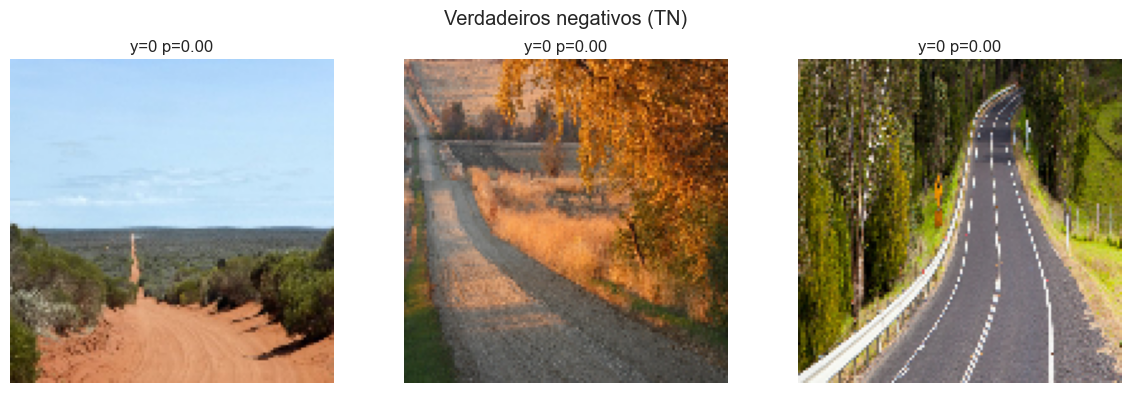

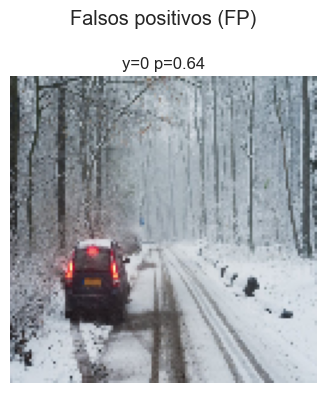

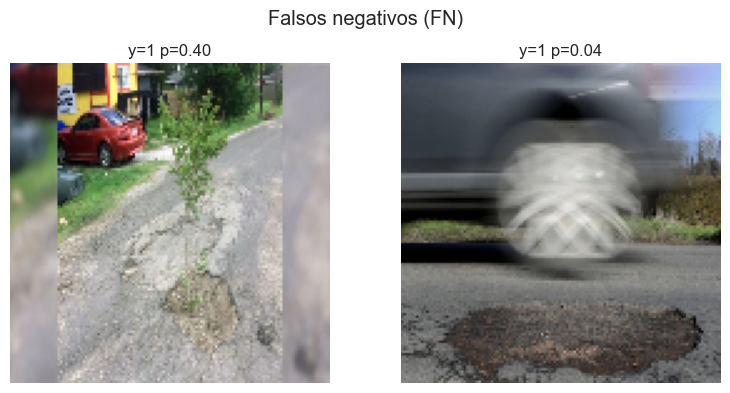

In [33]:
# Exemplos de acertos e erros (TP, TN, FP, FN) no conjunto de validação.
preds = resultados_tl["predicoes"]
probs_pos = resultados_tl["probabilidades_positivo"]

tp = np.where((y_valid == 1) & (preds == 1))[0]
tn = np.where((y_valid == 0) & (preds == 0))[0]
fp = np.where((y_valid == 0) & (preds == 1))[0]
fn = np.where((y_valid == 1) & (preds == 0))[0]


def _mostrar(indices, titulo, n=3):
    if len(indices) == 0:
        print(titulo, ": nenhum exemplo")
        return
    fig, axes = plt.subplots(1, min(n, len(indices)), figsize=(4 * min(n, len(indices)), 4))
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, indices[:n]):
        ax.imshow(X_valid[idx])
        ax.set_title(f"y={y_valid[idx]} p={probs_pos[idx]:.2f}")
        ax.axis("off")
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


_mostrar(tp, "Verdadeiros positivos (TP)")
_mostrar(tn, "Verdadeiros negativos (TN)")
_mostrar(fp, "Falsos positivos (FP)")
_mostrar(fn, "Falsos negativos (FN)")


In [34]:
# Grad-CAM (opcional) — exige backbone MobileNetV2 no modelo.
if CONFIG["USE_GRADCAM"] and "mobilenet" in CONFIG["BACKBONE"].lower():
    idx = int(tp[0]) if len(tp) > 0 else 0
    x_pp = preprocess_numpy_rgb_01(np.expand_dims(X_valid[idx], 0), CONFIG["BACKBONE"])
    try:
        heat = grad_cam_mobilenet(modelo_tl, x_pp[0], classe_idx=1)
        plt.figure(figsize=(6, 4))
        plt.imshow(X_valid[idx])
        plt.imshow(heat, cmap="jet", alpha=0.35)
        plt.title("Grad-CAM (classe buracos)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Grad-CAM omitido:", e)
else:
    print("Grad-CAM desligado ou backbone não MobileNetV2.")


Grad-CAM omitido: 'ReLU' object has no attribute 'output_shape'


## Conclusão executiva

Preencha após a execução com os números obtidos no seu ambiente:

- **Acurácia de validação (transfer)** foi de **see metricas_transfer** frente ao **baseline** em **metricas_baseline**.
- **Ganho esperado:** transfer learning costuma melhorar generalização com menos dados ao reutilizar filtros ImageNet; o ganho exato depende do dataset.
- **Próximos passos:** validação em campo com imagens novas (domínio diferente), quantização para mobile (TFLite), monitoramento de deriva e rotulagem ativa para classes raras.

---

**Artefatos:** `outputs/results.csv` (métricas por época e fase), `models/transfer_phase1_best.keras`, `models/transfer_phase2_best.keras`.


In [35]:
# Inferência standalone — carrega o melhor modelo e classifica uma imagem nova (campo).
def predizer_caminho_imagem(caminho: Path | str, modelo: tf.keras.Model, nome_backbone: str) -> tuple[str, float]:
    # Lê JPG, redimensiona como no treino, aplica pré-processamento ImageNet e retorna classe e prob. buracos.
    cv2 = obter_cv2()
    caminho = Path(caminho)
    img_bgr = cv2.imread(str(caminho))
    if img_bgr is None:
        raise FileNotFoundError(caminho)
    img_bgr = cv2.resize(img_bgr, (IMG_W, IMG_H))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    batch = np.expand_dims(img_rgb, 0)
    x = preprocess_numpy_rgb_01(batch, nome_backbone)
    prob = modelo.predict(x, verbose=0)[0]
    rotulo = int(np.argmax(prob))
    prob_buraco = float(prob[1])
    nome_classe = "normal" if rotulo == 0 else "potholes"
    return nome_classe, prob_buraco


# Defina CONFIG["DEMO_IMAGE"] para um caminho real ou use variável abaixo:
_demo = CONFIG["DEMO_IMAGE"]
if _demo is not None and Path(_demo).is_file():
    cls, p = predizer_caminho_imagem(_demo, modelo_tl, CONFIG["BACKBONE"])
    print(f"Arquivo: {_demo} -> {cls} (P(buracos)={p:.4f})")
else:
    print("Defina CONFIG['DEMO_IMAGE'] para testar inferência em arquivo único.")


Defina CONFIG['DEMO_IMAGE'] para testar inferência em arquivo único.


### Teste com imagens reais

In [41]:
from pathlib import Path

minha_foto = Path(r"C:\Users\luccasoares\Desktop\Civil-Engineering\buraco.jpeg") # ajuste o caminho

classe, prob = predizer_caminho_imagem(minha_foto, modelo_tl, CONFIG["BACKBONE"])
print(f"Classe: {classe} | P(buracos) = {prob:.4f}")

Classe: normal | P(buracos) = 0.0001
